## Rational Numbers

In [1]:
from sympy import Rational

display(Rational(1, 2))
display(Rational('1/2'))

1/2

1/2

## Constants & Physical Units

In [2]:
from sympy.physics.units import Quantity, length, meter
from sympy.physics.units.systems.si import SI
from sympy.physics.units import convert_to

Proteus = Quantity('P')

# 'Proteus' is a measurement of length
SI.set_quantity_dimension(Proteus, length)

# conversion factor (1 P= 1.114514 meters)
SI.set_quantity_scale_factor(Proteus, 1.114514 * meter)

display(convert_to(1919810 * meter, Proteus))

1722553.50762754*P

In [3]:
from sympy.physics.units import convert_to, speed_of_light, meter, second, liters, hour

from sympy import init_printing
init_printing(fold_short_frac=True) # Use inline format for simple fractions

display(convert_to(speed_of_light, [meter, second]))
display(convert_to(speed_of_light, [meter, hour]))
init_printing(fold_short_frac=False)

In [4]:
from sympy.physics.units import meters, kilometer
from sympy.physics.units.util import quantity_simplify

display((1000 * meters/ (2 * kilometer)))
display((1000 * meters/ (2 * kilometer)).simplify())

## Filter Results in Range for Non-linear Equations

In [5]:
from sympy import symbols, cos, sin, nonlinsolve, Eq, Set, Interval, EmptySet
from IPython.display import display, Markdown
import itertools

def filter(sols, domains, param_name="n"):
    assert isinstance(sols, Set), f"Solution DNE, got {type(sols)}"
    ret = []
    # Iterate outer solution set
    for sol in sols.args:
        print(f"\n[DEBUG] Current solution: {sol}")
        
        # Then iterate varables inside a solution, filter variable value with the domain specified,
        # and enumerate all possible groups of variables that its value is an interval
        filed_vars = []
        for i, var in enumerate(sol):
            print(f"[DEBUG][{i}] type={type(var).__name__}")
            print(f"[DEBUG]    value: {var}")
            
            # If this variable is an interval
            if isinstance(var, Set):
                # filter using intersect
                if (filed_var := var.intersect(domains[i])) != EmptySet:
                    filed_vars.append(filed_var)
            else:  # if just a single number:
                if var in domains[i]: filed_vars.append({var})
        
        # If lacks one variable, drop this solution
        if len(filed_vars) < len(sol):
            print(f"[DEBUG]    dropped filtered solution: {filed_vars}")
            break
        else:
            print(f"[DEBUG]    filtered solution: {filed_vars}")
        
        # Rearrange solutions with cartesian product (e.g. every possible x, y, z combination)
        enumed_sol = []
        enumed_sol += itertools.product(*filed_vars)
        print(f"[DEBUG]    enumerated solution: {enumed_sol}")

        ret.append(set(enumed_sol))  # deduplicates with hashset
    return ret

if __name__ == "__main__":
    x, y, z = symbols("x y z", real=True)

    # System of equations, with no definite solution
    eq1 = Eq(x * y, z)
    eq2 = Eq(-x * y, z)
    eq3 = Eq(cos(x) + sin(y), z)
    
    sols = nonlinsolve([eq1, eq2, eq3], [x, y, z])

    display(Markdown("Raw solutions:"))
    display(sols)

    # We need make sure the solution set is reasonable. restrict the domain for each variable
    domains = [
        Interval(-10, 10),
        Interval(-10, 10),
        Interval(-10, 10),
    ]
    filtered_sols = filter(sols, domains)
    
    display(Markdown("Filtered solutions:"))
    for i in filtered_sols:
        display(i)

Raw solutions:


[DEBUG] Current solution: (0, ImageSet(Lambda(_n, 2*_n*pi + 3*pi/2), Integers), 0)
[DEBUG][0] type=Zero
[DEBUG]    value: 0
[DEBUG][1] type=ImageSet
[DEBUG]    value: ImageSet(Lambda(_n, 2*_n*pi + 3*pi/2), Integers)
[DEBUG][2] type=Zero
[DEBUG]    value: 0
[DEBUG]    filtered solution: [{0}, {-5*pi/2, -pi/2, 3*pi/2}, {0}]
[DEBUG]    enumerated solution: [(0, -5*pi/2, 0), (0, -pi/2, 0), (0, 3*pi/2, 0)]

[DEBUG] Current solution: (ImageSet(Lambda(_n, 2*_n*pi + pi/2), Integers), 0, 0)
[DEBUG][0] type=ImageSet
[DEBUG]    value: ImageSet(Lambda(_n, 2*_n*pi + pi/2), Integers)
[DEBUG][1] type=Zero
[DEBUG]    value: 0
[DEBUG][2] type=Zero
[DEBUG]    value: 0
[DEBUG]    filtered solution: [{-3*pi/2, pi/2, 5*pi/2}, {0}, {0}]
[DEBUG]    enumerated solution: [(-3*pi/2, 0, 0), (pi/2, 0, 0), (5*pi/2, 0, 0)]

[DEBUG] Current solution: (ImageSet(Lambda(_n, 2*_n*pi + 3*pi/2), Integers), 0, 0)
[DEBUG][0] type=ImageSet
[DEBUG]    value: ImageSet(Lambda(_n, 2*_n*pi + 3*pi/2), Integers)
[DEBUG][1] type=Ze

Filtered solutions:

## Analyze a Function Using SymPy & Matplotlib

In [6]:
from sympy import init_session
#from sympy.parsing.latex import parse_latex
from IPython.display import Math, Markdown

init_session()

def prtmd(s):
    display(Markdown(s))

def prttex(s):
    display(Math(s))

IPython console for SymPy 1.14.0 (Python 3.14.4-64-bit) (ground types: python)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.14.0/



In [7]:
f = x + 8000 / x
f_p=f.diff()
f_pp=f.diff(x, 2) # or f.diff(x, x)

pprint(f) # Pretty print (for console)

# Display f, f', f''
prttex(rf"f={latex(f)}")
prttex(rf"f'={latex(f_p)}")
prttex(rf"f''={latex(f_pp)}")

    8000
x + ────
     x  


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
sol=solveset(f_p, x) # Solve f'=0
prtmd(r"Solution of $f'$")
items = [rf"x = {latex(i)} \approx {N(i):.4f}" for i in sol] # use N() to get numeric value
prttex(r",\,".join(items))

prttex(rf"f'(80)={latex(f_p.evalf(subs={x:80}))}") # .evalf() is equivalent to N() to get numeric evaluation
prttex(rf"f'(80)={latex(f_p.subs(x, 80))}") # Using f.subs() to get symbolic evaluation
prttex(rf'\lim_{{x\to 0}}f(x)={latex(limit(f, x, 0))}') # Display limit f(x) as x approaches 0

# limit at x approaches plus/minus infinity
prtmd(rf"Limit: ${latex(limit(f, x, -oo))}$")
prtmd(rf"Limit: ${latex(limit(f, x, oo))}$")

Solution of $f'$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Limit: $-\infty$

Limit: $\infty$

[DEBUG] curve: 0, cartesian line: x + 8000/x for x over (-100.0, 100.0)


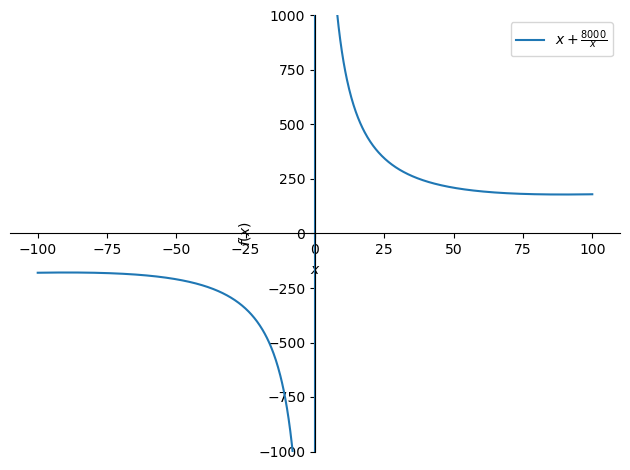

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Plot the function, ylim is a suggestion and doesn't always work
p = plot((f, (x, -100, 100)), ylim=[-1000, 1000], legend=True, show=False)
# SymPy's plot implements __iter__, making it iterable over its series (curves)
for i, series in enumerate(p):
    print(f"[DEBUG] curve: {i}, {series}")
    p[i].label = p[i].get_label(use_latex=True) # Use LaTeX form

# NOTE: without matplotlib, sympy will fallback to text-based backend
p.show()

## Implicit Differentiation in SymPy

In [10]:
from sympy import symbols, sqrt, idiff
from sympy import latex
from IPython.display import Math, Markdown

def prtmd(s):
    display(Markdown(s))

def prttex(s):
    display(Math(s))

x, y = symbols('x y')

eq = Eq((x - y)**2, x + y - 1)

# Compute the implicit derivative of y with respect to x
dy_dx = idiff(eq.lhs - eq.rhs, y, x)

DD = r"\mathrm{d}"
prttex(rf"\frac{{{DD}y}}{{{DD}x}}={latex(dy_dx)}")

<IPython.core.display.Math object>

### Use `Function()` and `diff()`

In [11]:
x = symbols('x')
y = Function('y')(x)

# Define the expression
eq = Eq((x - y)**2, x + y - 1)
expr = eq.lhs - eq.rhs

# Differentiate the expression with respect to x
dexpr = diff(expr, x)

prttex(rf"\frac{{{DD}y}}{{{DD}x}}={latex(dexpr)}")

# use solve() to move dy_dx to side
dy_dx = solve(dexpr, diff(y, x))[0]

DD = r"\mathrm{d}"
prttex(rf"\frac{{{DD}y}}{{{DD}x}}={latex(dy_dx)}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Reference
1. [Implicit Differentiation Sympy](https://stackoverflow.com/a/35487338/26004653)
2. [Displaying solutions within a certain range when using sympy solve command](https://stackoverflow.com/a/62171487/26004653)